<a href="https://colab.research.google.com/github/RaniellyPatricia/predicao-abandono-escolar-mg/blob/main/notebooks/04_modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Separação das variáveis explicativas e da variável-alvo

Nesta etapa, serão separadas as variáveis explicativas, representadas por `X`, e a variável-alvo, representada por `y`.

A variável `TAXA_ABANDONO_ANOS_FINAIS` não será utilizada como variável explicativa, pois a classe de abandono foi criada a partir dela. Utilizá-la no treinamento causaria vazamento de informação, fazendo com que o modelo tivesse acesso direto à resposta que deveria prever.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [3]:
url_dataset = (
    "https://raw.githubusercontent.com/"
    "RaniellyPatricia/predicao-abandono-escolar-mg/"
    "main/data/processed/dataset_abandono_mg_2023_com_classes.csv"
)

df = pd.read_csv(url_dataset)

print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

df.head()

Quantidade de linhas: 853
Quantidade de colunas: 13


,ANO,CO_MUNICIPIO,NO_MUNICIPIO,QTD_ALUNOS_INSE,MEDIA_INSE,TDI_ANOS_FINAIS,MEDIA_ALUNOS_TURMA_ANOS_FINAIS,PERC_ESCOLAS_BAIXA_REGULARIDADE_DOCENTE,PERC_ESCOLAS_MEDIA_BAIXA_REGULARIDADE_DOCENTE,PERC_ESCOLAS_MEDIA_ALTA_REGULARIDADE_DOCENTE,PERC_ESCOLAS_ALTA_REGULARIDADE_DOCENTE,TAXA_ABANDONO_ANOS_FINAIS,CLASSE_ABANDONO
0,2023,3136959,Juvenília,228,4.4254,8.8,17.5,0.0,18.2,54.5,27.3,0.8,Médio risco
1,2023,3136900,Juruaia,306,5.1850,17.4,31.6,14.3,42.9,42.8,0.0,3.4,Alto risco
2,2023,3136702,Juiz de Fora,9283,5.1931,19.2,24.9,11.1,58.9,27.2,2.8,1.2,Médio risco
3,2023,3136652,Juatuba,966,5.1363,8.0,24.2,23.5,52.9,11.8,11.8,0.1,Baixo risco
4,2023,3136603,Nova União,191,5.0039,22.5,28.8,0.0,20.0,80.0,0.0,0.6,Médio risco


In [4]:
df["CLASSE_ABANDONO"].value_counts(normalize=True)*100

,proportion
CLASSE_ABANDONO,
Médio risco,48.769050
Baixo risco,26.377491
Alto risco,24.853458


In [6]:
variaveis_explicativas = [
    "QTD_ALUNOS_INSE",
    "MEDIA_INSE",
    "TDI_ANOS_FINAIS",
    "MEDIA_ALUNOS_TURMA_ANOS_FINAIS",
    "PERC_ESCOLAS_BAIXA_REGULARIDADE_DOCENTE",
    "PERC_ESCOLAS_MEDIA_BAIXA_REGULARIDADE_DOCENTE",
    "PERC_ESCOLAS_MEDIA_ALTA_REGULARIDADE_DOCENTE",
    "PERC_ESCOLAS_ALTA_REGULARIDADE_DOCENTE"
]
X = df[variaveis_explicativas]
y = df["CLASSE_ABANDONO"]

print("Variáveis explicativas:", variaveis_explicativas)
print("Variável-alvo:", "CLASSE_ABANDONO")

Variáveis explicativas: ['QTD_ALUNOS_INSE', 'MEDIA_INSE', 'TDI_ANOS_FINAIS', 'MEDIA_ALUNOS_TURMA_ANOS_FINAIS', 'PERC_ESCOLAS_BAIXA_REGULARIDADE_DOCENTE', 'PERC_ESCOLAS_MEDIA_BAIXA_REGULARIDADE_DOCENTE', 'PERC_ESCOLAS_MEDIA_ALTA_REGULARIDADE_DOCENTE', 'PERC_ESCOLAS_ALTA_REGULARIDADE_DOCENTE']
Variável-alvo: CLASSE_ABANDONO


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamanho do conjunto de treinamento:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)

print("Distribuição no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True) * 100)

Tamanho do conjunto de treinamento: (597, 8)
Tamanho do conjunto de teste: (256, 8)
Distribuição no treino:
CLASSE_ABANDONO
Médio risco    48.743719
Baixo risco    26.465662
Alto risco     24.790620
Name: proportion, dtype: float64

Distribuição no teste:
CLASSE_ABANDONO
Médio risco    48.828125
Baixo risco    26.171875
Alto risco     25.000000
Name: proportion, dtype: float64


## Treinamento dos modelos de classificação

Nesta etapa, serão treinados três modelos de classificação: Regressão Logística, Árvore de Decisão e Random Forest.

A Regressão Logística será utilizada como modelo de referência, por ser simples e interpretável. A Árvore de Decisão permite visualizar regras de decisão de forma mais intuitiva. Já o Random Forest combina várias árvores de decisão, tendendo a apresentar maior robustez e melhor capacidade de generalização.

In [13]:
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Árvore de Decisão": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5
    )
}

In [14]:
resultados = []

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    resultados.append({
        "Modelo": nome_modelo,
        "Acurácia": acuracia,
        "Precisão macro": precisao,
        "Recall macro": recall,
        "F1-score macro": f1
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Modelo,Acurácia,Precisão macro,Recall macro,F1-score macro
0,Regressão Logística,0.535156,0.528925,0.455877,0.459577
1,Árvore de Decisão,0.500000,0.467777,0.416394,0.413398
2,Random Forest,0.523438,0.512251,0.421527,0.408365


In [15]:
for nome_modelo, modelo in modelos.items():
    y_pred = modelo.predict(X_test)

    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)

    print(classification_report(y_test, y_pred))

Regressão Logística
              precision    recall  f1-score   support

  Alto risco       0.59      0.34      0.44        64
 Baixo risco       0.45      0.22      0.30        67
 Médio risco       0.54      0.80      0.64       125

    accuracy                           0.54       256
   macro avg       0.53      0.46      0.46       256
weighted avg       0.53      0.54      0.50       256

Árvore de Decisão
              precision    recall  f1-score   support

  Alto risco       0.47      0.23      0.31        64
 Baixo risco       0.41      0.24      0.30        67
 Médio risco       0.52      0.78      0.63       125

    accuracy                           0.50       256
   macro avg       0.47      0.42      0.41       256
weighted avg       0.48      0.50      0.46       256

Random Forest
              precision    recall  f1-score   support

  Alto risco       0.42      0.12      0.19        64
 Baixo risco       0.59      0.28      0.38        67
 Médio risco       0.52

In [16]:
classes_ordem = ["Baixo risco", "Médio risco", "Alto risco"]

for nome_modelo, modelo in modelos.items():
    y_pred = modelo.predict(X_test)

    matriz = confusion_matrix(
        y_test,
        y_pred,
        labels=classes_ordem
    )

    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)
    print(pd.DataFrame(
        matriz,
        index=[f"Real: {classe}" for classe in classes_ordem],
        columns=[f"Previsto: {classe}" for classe in classes_ordem]
    ))

Regressão Logística
                   Previsto: Baixo risco  Previsto: Médio risco  \
Real: Baixo risco                     15                     45   
Real: Médio risco                     17                    100   
Real: Alto risco                       1                     41   

                   Previsto: Alto risco  
Real: Baixo risco                     7  
Real: Médio risco                     8  
Real: Alto risco                     22  
Árvore de Decisão
                   Previsto: Baixo risco  Previsto: Médio risco  \
Real: Baixo risco                     16                     42   
Real: Médio risco                     20                     97   
Real: Alto risco                       3                     46   

                   Previsto: Alto risco  
Real: Baixo risco                     9  
Real: Médio risco                     8  
Real: Alto risco                     15  
Random Forest
                   Previsto: Baixo risco  Previsto: Médio risco  \
Real: B

## Modelo base para comparação

Antes de interpretar os modelos treinados, será criado um modelo base simples. Esse modelo sempre prevê a classe mais frequente do conjunto de treino.

A comparação com esse modelo é importante para verificar se os algoritmos treinados realmente apresentam desempenho superior a uma estratégia ingênua de classificação.

In [17]:
from sklearn.dummy import DummyClassifier

modelo_base = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

modelo_base.fit(X_train, y_train)

y_pred_base = modelo_base.predict(X_test)

print("Acurácia do modelo base:", accuracy_score(y_test, y_pred_base))
print("F1-score macro do modelo base:", f1_score(y_test, y_pred_base, average="macro"))

print(classification_report(y_test, y_pred_base))

Acurácia do modelo base: 0.48828125
F1-score macro do modelo base: 0.21872265966754156
              precision    recall  f1-score   support

  Alto risco       0.00      0.00      0.00        64
 Baixo risco       0.00      0.00      0.00        67
 Médio risco       0.49      1.00      0.66       125

    accuracy                           0.49       256
   macro avg       0.16      0.33      0.22       256
weighted avg       0.24      0.49      0.32       256



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Modelos com balanceamento de classes

Os modelos iniciais apresentaram tendência de classificar muitos municípios como `Médio risco`, que é a classe mais frequente da base.

Para tentar reduzir esse comportamento, serão testadas versões balanceadas dos modelos, utilizando o parâmetro `class_weight="balanced"`. Esse parâmetro atribui pesos maiores às classes menos frequentes durante o treinamento, buscando melhorar a identificação das classes `Baixo risco` e `Alto risco`.

In [19]:
modelos_balanceados = {
    "Regressão Logística Balanceada": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    ]),
    "Arvore de decisão Balanceada": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ),
    "Random Forest Balanceado": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        class_weight="balanced"
    )
}



In [24]:
resultados_balanceados = []

for nome_modelo, modelo in modelos_balanceados.items():
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    resultados_balanceados.append({
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-score macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

df_resultados_balanceados = pd.DataFrame(resultados_balanceados)

df_resultados_balanceados

,Modelo,Acurácia,Precisão macro,Recall macro,F1-score macro
0,Regressão Logística,0.468750,0.501362,0.524871,0.469552
1,Arvore de decisão Balanceada,0.433594,0.468434,0.479396,0.433664
2,Random Forest Balanceado,0.523438,0.531189,0.555279,0.521050


In [26]:
for nome_modelo, modelo in modelos_balanceados.items():
    y_pred = modelo.predict(X_test)

    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)

    print(classification_report(y_test, y_pred, zero_division=0))

Regressão Logística
              precision    recall  f1-score   support

  Alto risco       0.44      0.73      0.55        64
 Baixo risco       0.38      0.55      0.45        67
 Médio risco       0.68      0.29      0.40       125

    accuracy                           0.47       256
   macro avg       0.50      0.52      0.47       256
weighted avg       0.54      0.47      0.45       256

Arvore de decisão Balanceada
              precision    recall  f1-score   support

  Alto risco       0.42      0.69      0.52        64
 Baixo risco       0.32      0.46      0.38        67
 Médio risco       0.67      0.29      0.40       125

    accuracy                           0.43       256
   macro avg       0.47      0.48      0.43       256
weighted avg       0.51      0.43      0.43       256

Random Forest Balanceado
              precision    recall  f1-score   support

  Alto risco       0.45      0.73      0.56        64
 Baixo risco       0.45      0.51      0.48        67
 

In [22]:
classes_ordem = ["Baixo risco", "Médio risco", "Alto risco"]

for nome_modelo, modelo in modelos_balanceados.items():
    y_pred = modelo.predict(X_test)

    matriz = confusion_matrix(
        y_test,
        y_pred,
        labels=classes_ordem
    )

    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)

    display(pd.DataFrame(
        matriz,
        index=[f"Real: {classe}" for classe in classes_ordem],
        columns=[f"Previsto: {classe}" for classe in classes_ordem]
    ))

Regressão Logística


,Previsto: Baixo risco,Previsto: Médio risco,Previsto: Alto risco
Real: Baixo risco,37,12,18
Real: Médio risco,48,36,41
Real: Alto risco,12,5,47


Arvore de decisão Balanceada


,Previsto: Baixo risco,Previsto: Médio risco,Previsto: Alto risco
Real: Baixo risco,31,13,23
Real: Médio risco,51,36,38
Real: Alto risco,15,5,44


Random Forest Balanceado


,Previsto: Baixo risco,Previsto: Médio risco,Previsto: Alto risco
Real: Baixo risco,34,13,20
Real: Médio risco,35,53,37
Real: Alto risco,6,11,47


In [27]:
df_todos_resultados = pd.concat(
    [
        df_resultados,
        df_resultados_balanceados
    ],
    ignore_index=True
)

df_todos_resultados = df_todos_resultados.sort_values(
    by="F1-score macro",
    ascending=False
)

df_todos_resultados

,Modelo,Acurácia,Precisão macro,Recall macro,F1-score macro
5,Random Forest Balanceado,0.523438,0.531189,0.555279,0.521050
3,Regressão Logística,0.468750,0.501362,0.524871,0.469552
0,Regressão Logística,0.535156,0.528925,0.455877,0.459577
4,Arvore de decisão Balanceada,0.433594,0.468434,0.479396,0.433664
1,Árvore de Decisão,0.500000,0.467777,0.416394,0.413398
2,Random Forest,0.523438,0.512251,0.421527,0.408365


### Interpretação dos modelos balanceados

Após a avaliação dos modelos iniciais, foram testadas versões com balanceamento de classes utilizando o parâmetro `class_weight="balanced"`. Essa estratégia foi aplicada porque os modelos iniciais apresentaram tendência de classificar muitos municípios como `Médio risco`, que é a classe mais frequente da base.

O balanceamento alterou o comportamento dos modelos. A Regressão Logística Balanceada e a Árvore de Decisão Balanceada passaram a identificar melhor as classes `Baixo risco` e `Alto risco`, mas apresentaram queda na acurácia geral. O Random Forest Balanceado apresentou o melhor desempenho geral entre todos os modelos avaliados.

O Random Forest Balanceado obteve acurácia de 52,34%, precisão macro de 0,531, recall macro de 0,555 e F1-score macro de 0,521. Embora a acurácia não tenha sido muito superior à dos modelos iniciais, o F1-score macro foi o melhor resultado obtido, indicando desempenho mais equilibrado entre as três classes.

A matriz de confusão mostrou que o Random Forest Balanceado conseguiu identificar corretamente 47 dos 64 municípios classificados como `Alto risco`, apresentando recall de 0,73 para essa classe. Esse resultado é relevante para o contexto educacional, pois municípios de alto risco são os que mais demandam atenção em políticas públicas e ações preventivas.

Por outro lado, o modelo apresentou maior dificuldade para classificar corretamente os municípios de `Médio risco`, confundindo parte deles com as classes `Baixo risco` e `Alto risco`. Esse comportamento indica que a separação entre as classes ainda é limitada pelos indicadores disponíveis.

De modo geral, o Random Forest Balanceado foi selecionado como o melhor modelo do projeto, pois apresentou o maior F1-score macro e melhor capacidade de identificar municípios de alto risco de abandono escolar.

In [30]:
melhor_modelo = modelos_balanceados["Random Forest Balanceado"]
importancias = melhor_modelo.feature_importances_

df_importancias = pd.DataFrame({
    "Variável": variaveis_explicativas,
    "Importância": importancias
})

df_importancias = df_importancias.sort_values(
    by="Importância",
    ascending=False
)

df_importancias

,Variável,Importância
2,TDI_ANOS_FINAIS,0.277200
0,QTD_ALUNOS_INSE,0.162103
3,MEDIA_ALUNOS_TURMA_ANOS_FINAIS,0.160661
1,MEDIA_INSE,0.119366
6,PERC_ESCOLAS_MEDIA_ALTA_REGULARIDADE_DOCENTE,0.086538
5,PERC_ESCOLAS_MEDIA_BAIXA_REGULARIDADE_DOCENTE,0.072129
4,PERC_ESCOLAS_BAIXA_REGULARIDADE_DOCENTE,0.070160
7,PERC_ESCOLAS_ALTA_REGULARIDADE_DOCENTE,0.051842


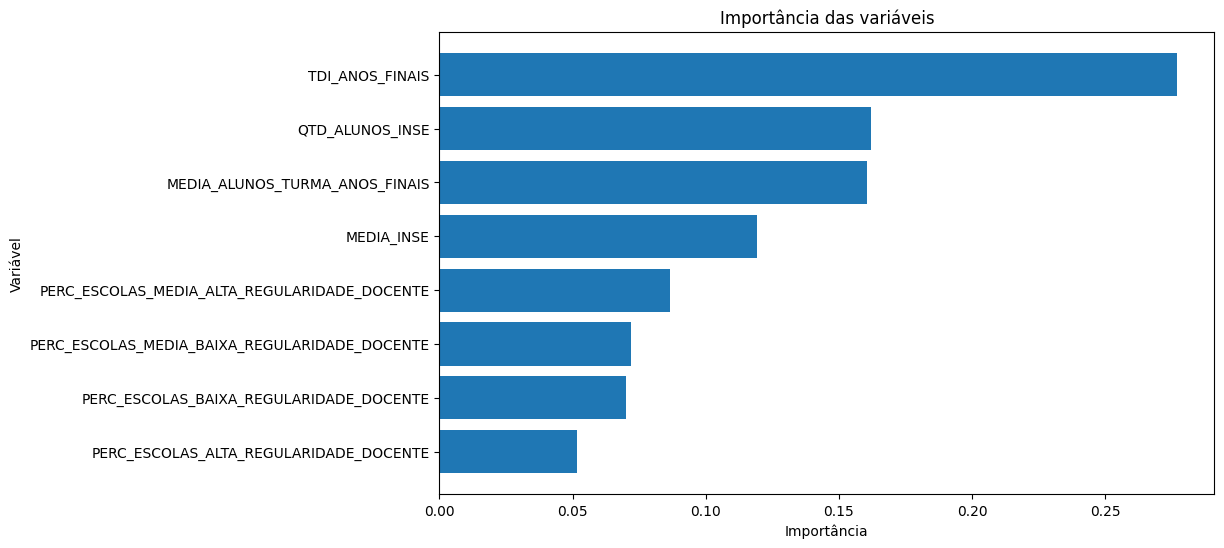

In [31]:
plt.figure(figsize=(10, 6))
plt.barh(df_importancias["Variável"], df_importancias["Importância"])

plt.title("Importância das variáveis")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.gca().invert_yaxis()

plt.show()

### Interpretação da importância das variáveis

A análise de importância das variáveis do Random Forest Balanceado mostra que a `TDI_ANOS_FINAIS` foi o indicador mais relevante para a classificação do risco de abandono escolar, com importância de 0,2772. Esse resultado reforça as análises anteriores, nas quais a Taxa de Distorção Idade-Série já havia apresentado a maior correlação com a Taxa de Abandono Escolar e também aumento progressivo entre as classes de baixo, médio e alto risco.

A segunda variável mais importante foi `QTD_ALUNOS_INSE`, com importância de 0,1621. Essa variável pode estar relacionada ao porte do município ou da rede escolar analisada, indicando que a quantidade de alunos considerada no cálculo do INSE também contribuiu para a classificação dos municípios.

A variável `MEDIA_ALUNOS_TURMA_ANOS_FINAIS` apareceu em terceiro lugar, com importância de 0,1607. Esse resultado sugere que a média de alunos por turma também possui papel relevante na classificação do risco de abandono, o que está de acordo com a análise exploratória, na qual os municípios de alto risco apresentaram turmas, em média, mais cheias.

A `MEDIA_INSE` apresentou importância intermediária, com valor de 0,1194. Embora sua correlação linear com a taxa de abandono tenha sido baixa, sua presença entre as variáveis mais importantes do Random Forest indica que o nível socioeconômico pode contribuir para a classificação quando analisado em conjunto com outros indicadores.

As variáveis relacionadas à regularidade docente apresentaram importâncias menores no modelo. Isso indica que, neste conjunto de dados e para o recorte analisado, esses indicadores tiveram menor contribuição para separar os municípios entre baixo, médio e alto risco de abandono escolar.

De modo geral, a importância das variáveis reforça que a distorção idade-série é o principal indicador associado à classificação do risco de abandono no modelo. No entanto, o resultado também mostra que o modelo utiliza uma combinação de fatores, especialmente TDI, porte da base de alunos, média de alunos por turma e INSE, confirmando o caráter multifatorial do abandono escolar.

## Aplicação do modelo ao município de Frutal

Após a escolha do melhor modelo, será realizada uma aplicação prática utilizando o município de Frutal como estudo de caso.

Para evitar que o modelo seja avaliado em um município que já tenha sido usado no treinamento, o Random Forest Balanceado será treinado com todos os municípios de Minas Gerais, exceto Frutal. Em seguida, o modelo será utilizado para prever a classe de risco de abandono escolar de Frutal.

In [32]:
df_frutal = df[
    df["NO_MUNICIPIO"].str.upper() == "FRUTAL"
].copy()

df_sem_frutal = df[
    df["NO_MUNICIPIO"].str.upper() != "FRUTAL"
].copy()

print("Quantidade de linhas de Frutal:", df_frutal.shape[0])
print("Quantidade de municípios usados no treinamento:", df_sem_frutal.shape[0])

Quantidade de linhas de Frutal: 1
Quantidade de municípios usados no treinamento: 852


In [33]:
X_sem_frutal = df_sem_frutal[variaveis_explicativas]
y_sem_frutal = df_sem_frutal["CLASSE_ABANDONO"]

X_frutal = df_frutal[variaveis_explicativas]
y_frutal_real = df_frutal["CLASSE_ABANDONO"]

print("classe real de Frutal", y_frutal_real)

classe real de Frutal 98    Médio risco
Name: CLASSE_ABANDONO, dtype: object


In [37]:
modelo_final = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=5,
    class_weight="balanced"
)

modelo_final.fit(X_sem_frutal, y_sem_frutal)

classe_prevista_frutal = modelo_final.predict(X_frutal)[0]

print("Classe real de Frutal:", y_frutal_real)
print("Classe prevista pelo modelo:", classe_prevista_frutal)

Classe real de Frutal: Médio risco
Classe prevista pelo modelo: Alto risco


In [38]:
probabilidades_frutal = modelo_final.predict_proba(X_frutal)[0]

df_probabilidades = pd.DataFrame({
    "Classe": modelo_final.classes_,
    "Probabilidade": probabilidades_frutal
}).sort_values(by="Probabilidade", ascending=False)

df_probabilidades

,Classe,Probabilidade
0,Alto risco,0.430117
2,Médio risco,0.348087
1,Baixo risco,0.221796


### Interpretação da predição de Frutal

O modelo final, Random Forest Balanceado, foi aplicado ao município de Frutal após ser treinado com os demais municípios de Minas Gerais. A classe real de Frutal, definida a partir dos quartis da Taxa de Abandono Escolar, é `Médio risco`. No entanto, o modelo classificou o município como `Alto risco`.

A análise das probabilidades mostra que o modelo atribuiu 43,01% de probabilidade para `Alto risco`, 34,81% para `Médio risco` e 22,18% para `Baixo risco`. Embora a maior probabilidade tenha sido atribuída à classe `Alto risco`, a diferença em relação à classe `Médio risco` não foi muito elevada, indicando uma classificação com certo grau de incerteza.

Esse resultado pode ser interpretado como um alerta. Frutal não apresentou taxa de abandono suficientemente alta para ser classificado como alto risco pela regra dos quartis, mas possui indicadores educacionais que aproximam seu perfil de municípios mais críticos. Entre esses fatores, destacam-se a Taxa de Distorção Idade-Série de 13,4% e a Média de Alunos por Turma de 26,2, ambas superiores à média dos municípios classificados como médio risco.

Dessa forma, a predição do modelo não deve ser interpretada como uma substituição da classificação real, mas como uma sinalização complementar. O resultado sugere que Frutal deve ser acompanhado com atenção, especialmente em relação ao atraso escolar nos Anos Finais.

## Síntese da modelagem

Nesta etapa, foram treinados e avaliados modelos de classificação para prever a classe de risco de abandono escolar dos municípios de Minas Gerais. Foram comparados três algoritmos principais: Regressão Logística, Árvore de Decisão e Random Forest, além de versões com balanceamento de classes.

O modelo base, que sempre previa a classe mais frequente, obteve acurácia de 48,83% e F1-score macro de 0,219. Esse resultado mostrou que a acurácia isolada poderia ser enganosa, pois o modelo base não identificou municípios de baixo ou alto risco.

Entre os modelos avaliados, o Random Forest Balanceado apresentou o melhor desempenho geral, com acurácia de 52,34%, precisão macro de 0,531, recall macro de 0,555 e F1-score macro de 0,521. Esse modelo foi escolhido por apresentar melhor equilíbrio entre as classes e maior capacidade de identificar municípios de alto risco.

A análise de importância das variáveis mostrou que a Taxa de Distorção Idade-Série dos Anos Finais foi o indicador mais relevante para a classificação do risco de abandono. Também se destacaram a quantidade de alunos considerada no INSE, a média de alunos por turma e o nível socioeconômico médio.

A aplicação do modelo ao município de Frutal mostrou que, embora sua classe real seja `Médio risco`, o modelo atribuiu maior probabilidade à classe `Alto risco`. Esse resultado reforça que Frutal apresenta indicadores que merecem acompanhamento, especialmente a distorção idade-série e a média de alunos por turma.

De modo geral, os modelos apresentaram desempenho moderado, indicando que os indicadores selecionados conseguem capturar alguns padrões associados ao abandono escolar, mas ainda possuem capacidade limitada de separação entre as classes. Essa limitação reforça o caráter multifatorial do abandono escolar e a necessidade de incorporar novos indicadores em estudos futuros.